# Taxa de mortalidade infantil

**Pergunta que este notebook responde:** quantas crianças morreram antes de
completar 1 ano para cada mil que nasceram vivas — e do que morreram?

A **taxa de mortalidade infantil** é um dos indicadores mais usados para avaliar
as condições de vida e a qualidade da atenção à saúde de uma população.

**Fontes:** SIM (óbitos) e SINASC (nascidos vivos) — combinados.
**Tempo estimado:** 5 a 8 minutos.

> Este notebook combina **duas bases**. Use um ano em que ambas estejam
> publicadas: o SINASC costuma ter mais defasagem que o SIM.

## Preparação

In [2]:
%pip install pysus nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

In [3]:
UF = "PR"
ANO = 2022    # precisa existir no SIM e no SINASC

## Passo 1 — Conferir se as duas bases têm o ano

In [4]:
from pysus import list_files

def anos_disponiveis(base):
    catalogo = list_files(dataset=base, state=UF)
    return sorted({int(a) for a in catalogo["year"].dropna()})

anos_sim = anos_disponiveis("sim")
anos_sinasc = anos_disponiveis("sinasc")
comuns = sorted(set(anos_sim) & set(anos_sinasc))

print(f"SIM    (óbitos):        até {max(anos_sim)}")
print(f"SINASC (nascimentos):   até {max(anos_sinasc)}")
print(f"Anos com as duas bases: {comuns[-6:]}")
print(f"\n{ANO} pode ser usado? {'sim' if ANO in comuns else 'NÃO — escolha um dos anos acima'}")

SIM    (óbitos):        até 2024
SINASC (nascimentos):   até 2022
Anos com as duas bases: [2017, 2018, 2019, 2020, 2021, 2022]

2022 pode ser usado? sim


## Passo 2 — Baixar as duas bases

In [5]:
from pysus import sim, sinasc

obitos = sim(state=UF, year=ANO, as_dataframe=True)
nascimentos = sinasc(state=UF, year=ANO, as_dataframe=True)

print(f"Óbitos (todas as idades): {len(obitos):>10,}")
print(f"Nascidos vivos:           {len(nascimentos):>10,}")

Óbitos (todas as idades):     89,808
Nascidos vivos:              140,637


## Passo 3 — Identificar os óbitos infantis

Aqui está o ponto delicado. No SIM, a coluna `IDADE` **não** é a idade em anos:
é um código de três dígitos em que o **primeiro dígito indica a unidade**:

| 1º dígito | Unidade |
|---|---|
| `0` | minutos |
| `1` | horas |
| `2` | dias |
| `3` | meses |
| `4` | anos |
| `5` | mais de 100 anos |
| `9` | ignorado |

Os dois dígitos seguintes são a quantidade. Assim, `230` significa 30 dias e
`483` significa 83 anos.

**Óbitos infantis** (menores de 1 ano) são, portanto, aqueles cujo primeiro
dígito é `0`, `1`, `2` ou `3` — quem morreu com idade contada em minutos,
horas, dias ou meses.

In [6]:
idade = obitos["IDADE"].astype(str)

print("Distribuição por unidade de idade:")
UNIDADES = {"0": "minutos", "1": "horas", "2": "dias", "3": "meses",
            "4": "anos", "5": ">100 anos", "9": "ignorado"}
for digito, quantidade in idade.str[0].value_counts().sort_index().items():
    print(f"  {digito} ({UNIDADES.get(digito, '?'):>10}): {quantidade:>8,}")

infantis = obitos[idade.str[0].isin(["0", "1", "2", "3"])]
print(f"\nÓbitos de menores de 1 ano: {len(infantis):,}")

Distribuição por unidade de idade:
  0 (   minutos):      106
  1 (     horas):      204
  2 (      dias):      697
  3 (     meses):      444
  4 (      anos):   87,816
  5 ( >100 anos):      454
  9 (  ignorado):       87

Óbitos de menores de 1 ano: 1,451


## Passo 4 — A taxa

A fórmula é direta:

$$\text{taxa} = \frac{\text{óbitos de menores de 1 ano}}{\text{nascidos vivos}} \times 1000$$

In [7]:
taxa = len(infantis) / len(nascimentos) * 1000

print(f"Estado: {UF} — {ANO}")
print(f"Óbitos de menores de 1 ano: {len(infantis):>10,}")
print(f"Nascidos vivos:             {len(nascimentos):>10,}")
print()
print(f"Taxa de mortalidade infantil: {taxa:.2f} por mil nascidos vivos")

Estado: PR — 2022
Óbitos de menores de 1 ano:      1,451
Nascidos vivos:                140,637

Taxa de mortalidade infantil: 10.32 por mil nascidos vivos


### Componentes da mortalidade infantil

A taxa costuma ser separada em dois componentes, porque as causas — e as
políticas capazes de reduzi-las — são diferentes:

- **Neonatal:** morte nos primeiros 27 dias (ligada à gestação, ao parto e à
  assistência ao recém-nascido).
- **Pós-neonatal:** de 28 dias a 1 ano incompleto (mais ligada a infecções,
  nutrição e condições de vida).

In [8]:
# minutos, horas ou até 27 dias => neonatal
dias = idade[idade.str[0] == "2"].str[1:].astype(int)
neonatal = (
    (idade.str[0].isin(["0", "1"])).sum()
    + (idade[idade.str[0] == "2"].str[1:].astype(int) <= 27).sum()
)
pos_neonatal = len(infantis) - neonatal

print(f"Neonatal (0 a 27 dias):      {neonatal:>7,}  "
      f"({neonatal/len(nascimentos)*1000:.2f} por mil)")
print(f"Pós-neonatal (28d a 1 ano):  {pos_neonatal:>7,}  "
      f"({pos_neonatal/len(nascimentos)*1000:.2f} por mil)")
print(f"Proporção neonatal:          {neonatal/len(infantis):.1%} dos óbitos infantis")

Neonatal (0 a 27 dias):          998  (7.10 por mil)
Pós-neonatal (28d a 1 ano):      453  (3.22 por mil)
Proporção neonatal:          68.8% dos óbitos infantis


## Passo 5 — Do que morreram

In [9]:
import pandas as pd

causas = (
    infantis["CAUSABAS"]
    .value_counts()
    .head(10)
    .rename_axis("CID-10")
    .reset_index(name="Óbitos")
)
causas["%"] = (causas["Óbitos"] / len(infantis) * 100).round(1)
causas

,CID-10,Óbitos,%
0,P000,94,6.5
1,P369,55,3.8
2,P010,48,3.3
3,P027,46,3.2
4,Q249,44,3.0
5,P220,42,2.9
6,P008,30,2.1
7,P011,29,2.0
8,W780,29,2.0
9,P77,29,2.0


Os códigos que começam com **P** são do capítulo "afecções originadas no período
perinatal" e os que começam com **Q**, "malformações congênitas" — juntos,
costumam responder pela maior parte dos óbitos infantis.

In [10]:
CAPITULOS = {
    "A": "Infecciosas", "B": "Infecciosas", "C": "Neoplasias",
    "E": "Endócrinas e metabólicas", "G": "Sistema nervoso",
    "I": "Aparelho circulatório", "J": "Aparelho respiratório",
    "K": "Aparelho digestivo", "P": "Afecções perinatais",
    "Q": "Malformações congênitas", "R": "Sintomas mal definidos",
    "V": "Causas externas", "W": "Causas externas",
    "X": "Causas externas", "Y": "Causas externas",
}

por_capitulo = (
    infantis["CAUSABAS"].str[0].map(CAPITULOS).fillna("Outros")
    .value_counts()
    .rename_axis("Grupo de causas")
    .reset_index(name="Óbitos")
)
por_capitulo["%"] = (por_capitulo["Óbitos"] / len(infantis) * 100).round(1)
por_capitulo

,Grupo de causas,Óbitos,%
0,Afecções perinatais,800,55.1
1,Malformações congênitas,370,25.5
2,Causas externas,88,6.1
3,Infecciosas,53,3.7
4,Aparelho respiratório,50,3.4
5,Sintomas mal definidos,33,2.3
6,Outros,14,1.0
7,Sistema nervoso,11,0.8
8,Aparelho circulatório,10,0.7
9,Endócrinas e metabólicas,8,0.6


## Passo 6 — Em gráfico

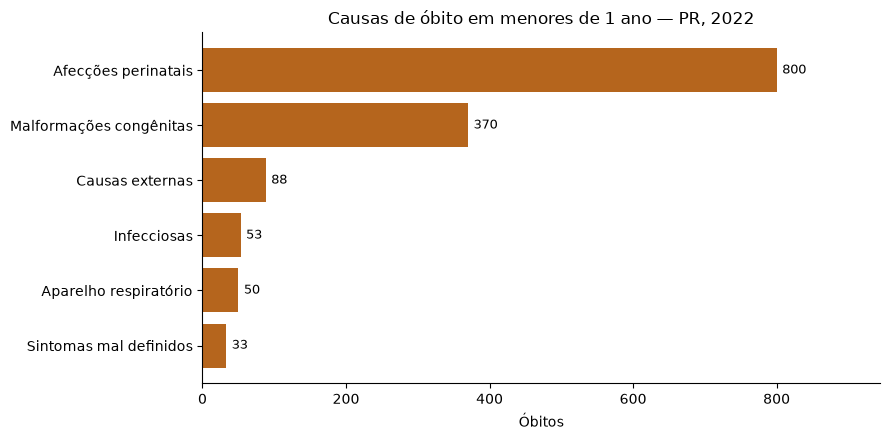

In [11]:
import matplotlib.pyplot as plt

grafico = por_capitulo.head(6).sort_values("Óbitos")

fig, ax = plt.subplots(figsize=(9, 4.5))
barras = ax.barh(grafico["Grupo de causas"], grafico["Óbitos"], color="#b5651d")
ax.bar_label(barras, padding=4, fontsize=9)

ax.set_title(f"Causas de óbito em menores de 1 ano — {UF}, {ANO}", fontsize=12)
ax.set_xlabel("Óbitos")
ax.set_xlim(0, grafico["Óbitos"].max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Como interpretar

- Taxas abaixo de 10 por mil são consideradas baixas no contexto brasileiro; a
  média nacional tem ficado em torno de 13 por mil.
- Em municípios pequenos, poucos óbitos fazem a taxa oscilar muito de um ano
  para o outro. Nesses casos, agrupe alguns anos antes de comparar.
- A alta proporção de óbitos **neonatais** costuma indicar que os ganhos mais
  fáceis (saneamento, vacinação, controle de diarreias) já foram obtidos, e que
  o desafio está na assistência ao pré-natal, ao parto e ao recém-nascido.

## Como adaptar

- **Outro estado ou ano:** mude `UF` e `ANO`.
- **Um município:** filtre `CODMUNRES` nas duas bases antes de contar.
- **Série histórica:** repita o cálculo para vários anos e monte um gráfico de
  linha da taxa ao longo do tempo.

---
*Notebook do projeto [PySusNoCode](https://github.com/cartaproale/PySusNoCode) —
um produto [Kraemer Academy](https://kraemeracademy.net).
Validado com dados reais do DATASUS.*